# Nashville Housing Hypothesis Testing

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from scipy.stats import kruskal, mannwhitneyu, spearmanr
from itertools import combinations

In [2]:
data = pd.read_excel(r'C:\Users\hp\Desktop\Shreya\Datasets\Nashville Housing Feature Engineered Data.xlsx')

In [3]:
data["Sale Date"] = pd.to_datetime(data["Sale Date"])
 
DECADE_ORDER = ["Pre-1900","1900-1919","1920-1939","1940-1959",
                "1960-1979","1980-1999","2000-2009","2010-2024"]
PRICE_ORDER  = ["Budget","Mid-Range","Upper-Mid","Luxury"]
data["Decade_Built"]   = pd.Categorical(data["Decade_Built"], categories=DECADE_ORDER, ordered=True)
data["Price_Category"] = pd.Categorical(data["Price_Category"], categories=PRICE_ORDER,  ordered=True)
data["Land_Use_Group"] = data["Land_Use_Group"].astype("category")

In [4]:
# Residential 
res = data[data["Bedrooms"] > 0].copy()
print(f"Full dataset:      {len(data):,} rows")
print(f"Residential only:  {len(res):,} rows\n")

Full dataset:      56,372 rows
Residential only:  51,166 rows



In [5]:
data.dtypes

Row no.                             int64
UniqueID                            int64
ParcelID                           object
Land Use                           object
Sale Price                          int64
Legal Reference                    object
Sold As Vacant                     object
Owner Name                         object
Acreage                           float64
TaxDistrict                        object
Land Value                          int64
Building Value                      int64
Total Value                         int64
Year Built                          int64
Bedrooms                            int64
Full Bath                           int64
Half Bath                           int64
Sale Date                  datetime64[ns]
Property Address_Street            object
Property City                      object
Owner Street Address               object
Owner City Address                 object
Owner State                        object
log_Sale_Price                    

In [6]:
BLUE,CORAL,GREEN,AMBER,PURPLE,TEAL,GRAY = (
    "#2563EB","#DC2626","#16A34A","#D97706","#7C3AED","#0891B2","#374151")
_style = ('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid'
          in plt.style.available else 'seaborn-whitegrid')
plt.style.use(_style)

In [7]:
def eta_squared_kruskal(groups):
    """
    eta_sq for Kruskal-Wallis.
    Formula: η_sq = (H - k + 1) / (n - k)
    where H = KW statistic, k = number of groups, n = total observations.
    Interpretation: proportion of rank-variance explained by group membership.
    """
    n = sum(len(g) for g in groups)
    k = len(groups)
    H, p = kruskal(*groups)
    eta_sq = (H - k + 1) / (n - k)
    return H, p, max(eta_sq, 0)   # clip to 0 (can be slightly negative by rounding)

In [8]:
def rank_biserial(group_a, group_b):
    """
    Rank-biserial correlation for Mann-Whitney U.
    Formula: r = 1 - (2U) / (n_a * n_b)
    Range: -1 to +1. Positive = group_a tends to be higher.
    """
    U, p = mannwhitneyu(group_a, group_b, alternative="two-sided")
    n_a, n_b = len(group_a), len(group_b)
    r = 1 - (2 * U) / (n_a * n_b)
    return U, p, r

In [9]:
def effect_label(val, metric="eta_sq"):
    """Human-readable effect size label."""
    thresholds = {"eta_sq": (0.01, 0.06, 0.14), "r": (0.1, 0.3, 0.5)}
    lo, med, hi = thresholds.get(metric, (0.01, 0.06, 0.14))
    av = abs(val)
    if av < lo:   return "Negligible"
    if av < med:  return "Small"
    if av < hi:   return "Medium"
    return "Large"

In [10]:
def dunn_posthoc(df_sub, group_col, value_col, alpha=0.05):
    """
    Manual Dunn post-hoc test with Bonferroni correction.
    Used after a significant Kruskal-Wallis to identify WHICH groups differ.
    Bonferroni correction: divide α by number of pairwise comparisons.
    """
    groups    = df_sub[group_col].unique()
    n_comp    = len(list(combinations(groups, 2)))
    alpha_adj = alpha / n_comp          # Bonferroni-adjusted threshold
    all_vals  = df_sub[value_col].values
    n_total   = len(all_vals)
    ranks     = stats.rankdata(all_vals)
    df_sub    = df_sub.copy()
    df_sub["_rank"] = ranks
 
    results = []
    for g1, g2 in combinations(groups, 2):
        r1 = df_sub[df_sub[group_col]==g1]["_rank"].values
        r2 = df_sub[df_sub[group_col]==g2]["_rank"].values
        n1, n2 = len(r1), len(r2)
        mean_rank_diff = abs(r1.mean() - r2.mean())
        se = np.sqrt((n_total*(n_total+1)/12) * (1/n1 + 1/n2))
        z  = mean_rank_diff / se
        p  = 2 * (1 - stats.norm.cdf(z))
        results.append({
            "Group A": g1, "Group B": g2,
            "Mean Rank A": round(r1.mean(), 1),
            "Mean Rank B": round(r2.mean(), 1),
            "Z": round(z, 3), "p-value": round(p, 5),
            "Sig (Bonferroni)": "Yes" if p < alpha_adj else "No"
        })
    return pd.DataFrame(results).sort_values("p-value")

### (i) Hypothesis 1

--------------------------------------------------------------------------------------------------------------------------------
- Hypothesis 1: Land Use vs Sale Price

  Ho: All land use groups have the same median sale price.
  H1: At least one land use group differs in median sale price.

In [26]:
print("="*65)
print("H1: Land Use Group vs Sale Price")
print("="*65)

groups_lu = [data[data["Land_Use_Group"]==g]["Sale Price"].values
             for g in res["Land_Use_Group"].unique()]

H1, p1, eta1 = eta_squared_kruskal(groups_lu)

print(f"Kruskal-Wallis:  H={H1:.2f}  p={p1:.2e}")
print(f"Effect size eta_sq={eta1:.4f}  [{effect_label(eta1)}]")
print(f"Decision: {'REJECT H0, groups differ significantly' if p1<0.05 else 'Fail to reject H0'}\n")
 
dunn1 = dunn_posthoc(data, "Land_Use_Group", "Sale Price")
print("Post-hoc Dunn test (Bonferroni corrected):")
display(dunn1)

H1: Land Use Group vs Sale Price
Kruskal-Wallis:  H=203.23  p=7.39e-45
Effect size eta_sq=0.0039  [Negligible]
Decision: REJECT H0, groups differ significantly

Post-hoc Dunn test (Bonferroni corrected):


,Group A,Group B,Mean Rank A,Mean Rank B,Z,p-value,Sig (Bonferroni)
0,Single Family,Condo,28183.3,29783.5,9.927,0.00000,Yes
1,Single Family,Vacant,28183.3,24799.7,13.933,0.00000,Yes
2,Single Family,Multi-Family,28183.3,24755.2,8.327,0.00000,Yes
4,Condo,Vacant,29783.5,24799.7,18.849,0.00000,Yes
5,Condo,Multi-Family,29783.5,24755.2,11.838,0.00000,Yes
8,Vacant,Commercial/Institutional,24799.7,32887.4,3.566,0.00036,Yes
9,Multi-Family,Commercial/Institutional,24755.2,32887.4,3.548,0.00039,Yes
3,Single Family,Commercial/Institutional,28183.3,32887.4,2.083,0.03725,No
6,Condo,Commercial/Institutional,29783.5,32887.4,1.373,0.16978,No
7,Vacant,Multi-Family,24799.7,24755.2,0.096,0.92334,No


### (ii) Hypothesis 2:

--------------------------------------------------------------------------------------------------------------------------------
* Hypothesis 2: City vs Sale Price 

  Ho: Median sale price is equal across cities.
  H1: At least one city differs in median sale price.

In [13]:
print("\n" + "="*65)
print("H2: City Location vs Sale Price (top 5 cities)")
print("="*65)
top_cities = data["Property City"].value_counts().head(5).index.tolist()
df_cities  = data[data["Property City"].isin(top_cities)]
groups_city = [df_cities[df_cities["Property City"]==c]["Sale Price"].values
               for c in top_cities]

H2, p2, eta_sq = eta_squared_kruskal(groups_city)

print(f"Kruskal-Wallis:  H={H2:.2f}  p={p2:.2e}")
print(f"Effect size eta_sq={eta_sq:.4f}  [{effect_label(eta_sq)}]")
print(f"Decision: {'REJECT H0, cities differ significantly' if p2<0.05 else 'Fail to reject H0'}\n")
 
for city in top_cities:
    s = df_cities[df_cities["Property City"]==city]["Sale Price"]
    print(f" {city:<15} n={len(s):>5,}  median=${s.median():>9,.0f}  IQR=${s.quantile(0.75)-s.quantile(0.25):>9,.0f}")

dunn2 = dunn_posthoc(df_cities, "Property City", "Sale Price")
print("\nPost-hoc Dunn test:")
display(dunn2)


H2: City Location vs Sale Price (top 5 cities)
Kruskal-Wallis:  H=3761.40  p=0.00e+00
Effect size eta_sq=0.0703  [Medium]
Decision: REJECT H0, cities differ significantly

 NASHVILLE       n=40,215  median=$  230,000  IQR=$  217,225
 ANTIOCH         n=6,286  median=$  157,900  IQR=$   83,490
 HERMITAGE       n=3,126  median=$  173,000  IQR=$  101,000
 MADISON         n=2,114  median=$  125,000  IQR=$   83,000
 BRENTWOOD       n=1,696  median=$  278,572  IQR=$  147,625

Post-hoc Dunn test:


,Group A,Group B,Mean Rank A,Mean Rank B,Z,p-value,Sig (Bonferroni)
0,MADISON,NASHVILLE,13402.7,28461.3,43.748,0.0,Yes
1,MADISON,ANTIOCH,13402.7,20477.4,18.241,0.0,Yes
2,MADISON,HERMITAGE,13402.7,22030.6,19.862,0.0,Yes
3,MADISON,BRENTWOOD,13402.7,33778.6,40.520,0.0,Yes
4,NASHVILLE,ANTIOCH,28461.3,20477.4,38.160,0.0,Yes
5,NASHVILLE,HERMITAGE,28461.3,22030.6,22.451,0.0,Yes
6,NASHVILLE,BRENTWOOD,28461.3,33778.6,13.905,0.0,Yes
7,ANTIOCH,HERMITAGE,20477.4,22030.6,4.601,0.0,Yes
8,ANTIOCH,BRENTWOOD,20477.4,33778.6,31.512,0.0,Yes
9,HERMITAGE,BRENTWOOD,22030.6,33778.6,25.252,0.0,Yes


### (iii) Hypothesis 3

--------------------------------------------------------------------------------------------------------------------------------
* Hypothesis 3: Sold As Vacant vs Sale Price

Ho: Vacant and non-vacant properties have the same median sale price.
H1: Vacant and non-vacant properties do not have the same median sale price.

In [14]:
print("\n" + "="*65)
print("H3: Sold As Vacant vs Sale Price")
print("="*65)

vacant     = data[data["Sold As Vacant"]=="Yes"]["Sale Price"].values
not_vacant = data[data["Sold As Vacant"]=="No"]["Sale Price"].values

U3, p3, r3 = rank_biserial(not_vacant, vacant)

print(f"Mann-Whitney U:  U={U3:.0f}  p={p3:.2e}")
print(f"Rank-biserial r={r3:.4f}  [{effect_label(r3,'r')}]")
print(f"Decision: {'REJECT H0' if p3<0.05 else 'Fail to reject H0'}")
print(f" Non-vacant median: ${np.median(not_vacant):,.0f}")
print(f" Vacant     median: ${np.median(vacant):,.0f}")
print(f"  r > 0, non-vacant properties sell for significantly more")


H3: Sold As Vacant vs Sale Price
Mann-Whitney U:  U=142480850  p=5.69e-93
Rank-biserial r=-0.1804  [Small]
Decision: REJECT H0
 Non-vacant median: $209,761
 Vacant     median: $143,000
  r > 0, non-vacant properties sell for significantly more


### (iv) Hypothesis 4

--------------------------------------------------------------------------------------------------------------------------------
* Hypothesis 4: Hot Market Era (2016+) vs Sale Price

In [15]:
print("\n" + "="*65)
print("H4: Hot Market Era (2016+) vs Sale Price")
print("="*65)

pre  = data[data["Hot_Market_Era"]==0]["Sale Price"].values
post = data[data["Hot_Market_Era"]==1]["Sale Price"].values

U4, p4, r4 = rank_biserial(post, pre)

print(f"Mann-Whitney U:  U={U4:.0f}  p={p4:.2e}")
print(f"Rank-biserial r={r4:.4f}  [{effect_label(r4,'r')}]")
print(f"Decision: {'REJECT H0' if p4<0.05 else 'Fail to reject H0'}")
print(f"  Pre-2016  median: ${np.median(pre):,.0f}   n={len(pre):,}")
print(f"  Post-2016 median: ${np.median(post):,.0f}   n={len(post):,}")


H4: Hot Market Era (2016+) vs Sale Price
Mann-Whitney U:  U=330851090  p=8.68e-88
Rank-biserial r=-0.1116  [Small]
Decision: REJECT H0
  Pre-2016  median: $199,500   n=42,299
  Post-2016 median: $229,435   n=14,073


### (v) Hypothesis 5

--------------------------------------------------------------------------------------------------------------------------------
* Hypothesis 5: Decade Built vs Sale Price

In [16]:
print("\n" + "="*65)
print("H5: Decade Built vs Sale Price")
print("="*65)

res_dec = res.dropna(subset=["Decade_Built"])

groups_dec = [res_dec[res_dec["Decade_Built"]==d]["Sale Price"].values
              for d in DECADE_ORDER if d in res_dec["Decade_Built"].values]

valid_labels = [d for d in DECADE_ORDER if d in res_dec["Decade_Built"].values]

H5, p5, eta5 = eta_squared_kruskal(groups_dec)
print(f"Kruskal-Wallis:  H={H5:.2f}  p={p5:.2e}")
print(f"Effect size eta_sq={eta5:.4f}  [{effect_label(eta5)}]")
print(f"Decision: {'REJECT H0' if p5<0.05 else 'Fail to reject H0'}\n")

for label, grp in zip(valid_labels, groups_dec):
    print(f" {label:<12}  n={len(grp):>5,}  median=${np.median(grp):>9,.0f}")


H5: Decade Built vs Sale Price
Kruskal-Wallis:  H=2342.73  p=0.00e+00
Effect size eta_sq=0.0457  [Small]
Decision: REJECT H0

 Pre-1900      n=   98  median=$  392,750
 1900-1919     n=  414  median=$  299,945
 1920-1939     n=3,505  median=$  253,000
 1940-1959     n=20,457  median=$  212,000
 1960-1979     n=20,548  median=$  200,000
 1980-1999     n=3,544  median=$  143,950
 2000-2009     n=  830  median=$  287,500
 2010-2024     n=1,770  median=$  357,000


### (vi) Hypothesis 6

--------------------------------------------------------------------------------------------------------------------------------
* Hypothesis 6: Spearman Correlations: numeric features vs Sale Price

In [17]:
print("\n" + "="*65)
print("H6: Spearman Correlations with Sale Price")
print("="*65)

corr_features = {
    "Bedrooms"              : "Count",
    "Full Bath"             : "Count",
    "Half Bath"             : "Count",
    "Total_Baths"           : "Engineered",
    "Size_Proxy"            : "Engineered",
    "Property_Age"          : "Engineered",
    "log_Building_Value"    : "Log-transformed",
    "log_Land_Value"        : "Log-transformed",
    "log_Acreage"           : "Log-transformed",
    "Sale_to_Assessed_Ratio": "Engineered",
    "Land_Value_Share"      : "Engineered",
    "Decade_Built_Ord"      : "Ordinal",
    "Sale_Year"             : "Temporal",
    "Hot_Market_Era"        : "Temporal",
}
print(f"\n  {'Feature':<25} {'Type':<17} {'r':>7}  {'p-value':>12}  {'Effect':>12}  {'Sig':>5}")

print("  " + "-"*80)
corr_results = []
for feat, ftype in corr_features.items():
    clean = data[[feat, "Sale Price"]].dropna()
    r, p  = spearmanr(clean[feat], clean["Sale Price"])
    sig   = "Yes" if p < 0.05 else "No"
    eff   = effect_label(abs(r), "r")
    corr_results.append({"Feature": feat, "Type": ftype, "r": r, "p": p,
                          "Effect": eff, "Sig": sig})
    print(f"  {feat:<25} {ftype:<17} {r:>7.3f}  {p:>12.2e}  {eff:>12}  {sig:>5}")

corr_df = pd.DataFrame(corr_results).sort_values("r", key=abs, ascending=False)
display(corr_df)


H6: Spearman Correlations with Sale Price

  Feature                   Type                    r       p-value        Effect    Sig
  --------------------------------------------------------------------------------
  Bedrooms                  Count               0.230      0.00e+00         Small    Yes
  Full Bath                 Count               0.315      0.00e+00        Medium    Yes
  Half Bath                 Count               0.082      1.08e-85    Negligible    Yes
  Total_Baths               Engineered          0.326      0.00e+00        Medium    Yes
  Size_Proxy                Engineered          0.303      0.00e+00        Medium    Yes
  Property_Age              Engineered          0.102     5.32e-131         Small    Yes
  log_Building_Value        Log-transformed     0.444      0.00e+00        Medium    Yes
  log_Land_Value            Log-transformed     0.502      0.00e+00         Large    Yes
  log_Acreage               Log-transformed     0.158      0.00e+00     

,Feature,Type,r,p,Effect,Sig
9,Sale_to_Assessed_Ratio,Engineered,0.682062,0.000000e+00,Large,Yes
7,log_Land_Value,Log-transformed,0.502010,0.000000e+00,Large,Yes
6,log_Building_Value,Log-transformed,0.444375,0.000000e+00,Medium,Yes
3,Total_Baths,Engineered,0.326102,0.000000e+00,Medium,Yes
1,Full Bath,Count,0.315176,0.000000e+00,Medium,Yes
4,Size_Proxy,Engineered,0.302589,0.000000e+00,Medium,Yes
0,Bedrooms,Count,0.229936,0.000000e+00,Small,Yes
8,log_Acreage,Log-transformed,0.158224,0.000000e+00,Small,Yes
12,Sale_Year,Temporal,0.123175,1.985758e-189,Small,Yes
5,Property_Age,Engineered,0.102305,5.315520e-131,Small,Yes


### (vii) Hypothesis 7

--------------------------------------------------------------------------------------------------------------------------------
* H0: Sale Price distributions are equal across all Tax Districts.  
  H1: At least one Tax District has a significantly different Sale Price distribution.

In [24]:
print(data['TaxDistrict'].value_counts())

Unknown                      30404
URBAN SERVICES DISTRICT      19979
GENERAL SERVICES DISTRICT     4554
CITY OF FOREST HILLS           407
CITY OF OAK HILL               393
CITY OF GOODLETTSVILLE         379
CITY OF BELLE MEADE            235
CITY OF BERRY HILL              21
Name: TaxDistrict, dtype: int64


In [20]:
groups = [
    group['Sale Price'].dropna().values
    for name, group in data.groupby('TaxDistrict')
]

In [28]:
stat, p_value = kruskal(*groups)

print("=" * 60)
print("KRUSKAL-WALLIS TEST: TAX DISTRICT vs SALE PRICE")
print("=" * 60)

H6, p6, eta6 = eta_squared_kruskal(groups)

print(f"Kruskal-Wallis:  H={H6:.2f}  p={p6:.2e}")
print(f"Effect size eta_sq={eta6:.4f}  [{effect_label(eta6)}]")
print(f"Decision: {'REJECT H0, groups differ significantly' if p1<0.05 else 'Fail to reject H0'}\n")
 

if p6 < alpha:
    print("\nResult: Reject H0")
    print("Conclusion: Sale Price differs significantly across Tax Districts.")
else:
    print("\nResult: Fail to Reject H0")
    print("Conclusion: No statistically significant difference in Sale Price across Tax Districts.")

dunn3 = dunn_posthoc(data, "TaxDistrict", "Sale Price")
print("\n Post-hoc Dunn test (Bonferroni corrected):")
display(dunn3)

KRUSKAL-WALLIS TEST: TAX DISTRICT vs SALE PRICE
Kruskal-Wallis:  H=4273.63  p=0.00e+00
Effect size eta_sq=0.0757  [Medium]
Decision: REJECT H0, groups differ significantly


Result: Reject H0
Conclusion: Sale Price differs significantly across Tax Districts.

 Post-hoc Dunn test (Bonferroni corrected):


,Group A,Group B,Mean Rank A,Mean Rank B,Z,p-value,Sig (Bonferroni)
0,GENERAL SERVICES DISTRICT,Unknown,18342.8,29734.8,44.057,0.00000,Yes
24,CITY OF BELLE MEADE,CITY OF BERRY HILL,54166.4,25742.1,7.669,0.00000,Yes
20,URBAN SERVICES DISTRICT,CITY OF OAK HILL,27098.6,49023.7,26.450,0.00000,Yes
19,URBAN SERVICES DISTRICT,CITY OF FOREST HILLS,27098.6,51351.6,29.765,0.00000,Yes
18,URBAN SERVICES DISTRICT,CITY OF BELLE MEADE,27098.6,54166.4,25.350,0.00000,Yes
16,CITY OF GOODLETTSVILLE,CITY OF OAK HILL,17151.5,49023.7,27.205,0.00000,Yes
15,CITY OF GOODLETTSVILLE,CITY OF FOREST HILLS,17151.5,51351.6,29.441,0.00000,Yes
14,CITY OF GOODLETTSVILLE,CITY OF BELLE MEADE,17151.5,54166.4,27.395,0.00000,Yes
26,CITY OF FOREST HILLS,CITY OF BERRY HILL,51351.6,25742.1,7.033,0.00000,Yes
11,Unknown,CITY OF OAK HILL,29734.8,49023.7,23.347,0.00000,Yes


### Summary

In [29]:
print("\n" + "="*65)
print("HYPOTHESIS TESTING SUMMARY")
print("="*65)
summary = [
    ("H1","Land Use Group vs Price",   "Kruskal-Wallis", f"p={p1:.1e}", f"eta_sq={eta1:.3f}", effect_label(eta1),      "REJECT H0"),
    ("H2","City vs Price",             "Kruskal-Wallis", f"p={p2:.1e}", f"eta_sq={eta_sq:.3f}", effect_label(eta_sq),  "REJECT H0"),
    ("H3","Sold As Vacant vs Price",   "Mann-Whitney",   f"p={p3:.1e}", f"r={r3:.3f}",    effect_label(r3,"r"),    "REJECT H0"),
    ("H4","Hot Market Era vs Price",   "Mann-Whitney",   f"p={p4:.1e}", f"r={r4:.3f}",    effect_label(r4,"r"),    "REJECT H0"),
    ("H5","Decade Built vs Price",     "Kruskal-Wallis", f"p={p5:.1e}", f"eta_sq={eta5:.3f}", effect_label(eta5),      "REJECT H0"),
    ("H6","TaxDistrict vs Price",     "Kruskal-Wallis",  f"p={p6:.1e}", f"eta_sq={eta6:.3f}", effect_label(eta6),      "REJECT H0"),
]
print(f"\n  {'Test':<5} {'Hypothesis':<28} {'Method':<16} {'p-value':<12} {'Effect size':<12} {'Magnitude':<12} {'Decision'}")
print("  " + "-"*100)
for row in summary:
    print(f"  {row[0]:<5} {row[1]:<28} {row[2]:<16} {row[3]:<12} {row[4]:<12} {row[5]:<12} {row[6]}")


HYPOTHESIS TESTING SUMMARY

  Test  Hypothesis                   Method           p-value      Effect size  Magnitude    Decision
  ----------------------------------------------------------------------------------------------------
  H1    Land Use Group vs Price      Kruskal-Wallis   p=7.4e-45    eta_sq=0.004 Negligible   REJECT H0
  H2    City vs Price                Kruskal-Wallis   p=0.0e+00    eta_sq=0.070 Medium       REJECT H0
  H3    Sold As Vacant vs Price      Mann-Whitney     p=5.7e-93    r=-0.180     Small        REJECT H0
  H4    Hot Market Era vs Price      Mann-Whitney     p=8.7e-88    r=-0.112     Small        REJECT H0
  H5    Decade Built vs Price        Kruskal-Wallis   p=0.0e+00    eta_sq=0.046 Small        REJECT H0
  H6    TaxDistrict vs Price         Kruskal-Wallis   p=0.0e+00    eta_sq=0.076 Medium       REJECT H0


### PLOTS

#### (1) Box plots: Land Use & City

In [18]:
print(data["Land_Use_Group"].value_counts())

Single Family               35192
Condo                       14346
Vacant                       5147
Multi-Family                 1635
Commercial/Institutional       52
Name: Land_Use_Group, dtype: int64


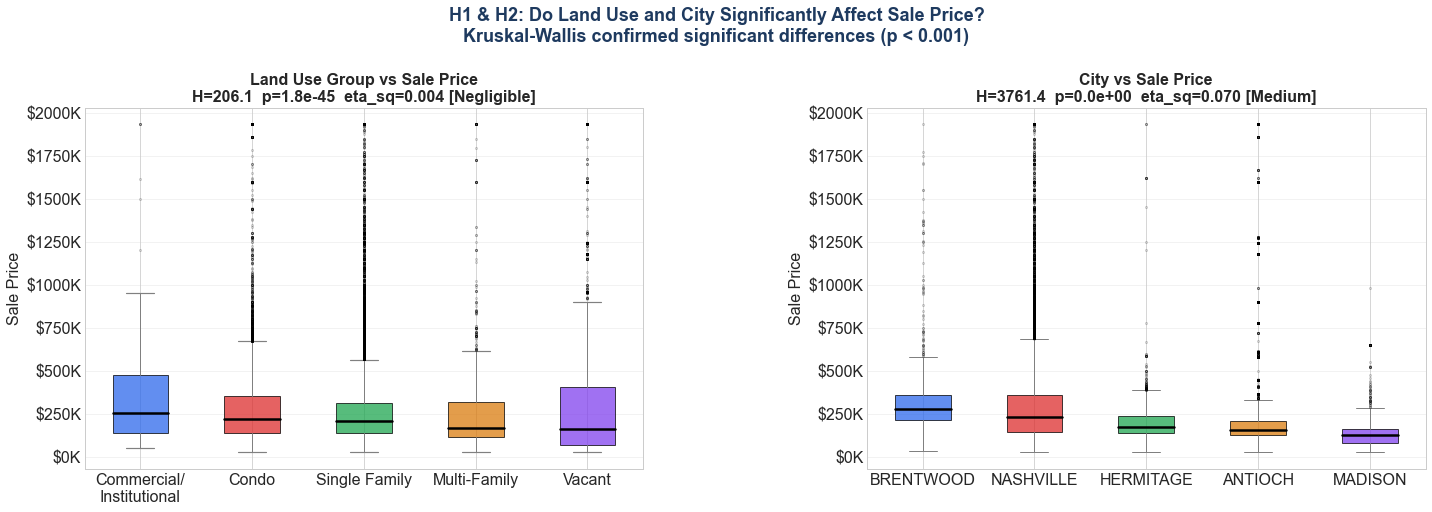

In [20]:
fig1, axes = plt.subplots(1, 2, figsize=(20, 7))
fig1.suptitle("H1 & H2: Do Land Use and City Significantly Affect Sale Price?\n"
              "Kruskal-Wallis confirmed significant differences (p < 0.001)",
              fontsize=18, fontweight="bold", color="#1E3A5F", y = 1.01)

# H1: Land Use
ax = axes[0]
lu_order = (data.groupby("Land_Use_Group")["Sale Price"]
               .median().sort_values(ascending=False).index.tolist())

lu_palette = [BLUE, CORAL, GREEN, AMBER, PURPLE, "#E91E63", "#00BCD4"]
data_lu = [data[data["Land_Use_Group"]==g]["Sale Price"].values for g in lu_order]

bp = ax.boxplot(data_lu, patch_artist=True, notch=False,
                medianprops=dict(color="black", linewidth=2.5),
                flierprops=dict(marker="o", markersize=2, alpha=0.2),
                whiskerprops=dict(color="gray", linewidth=1),
                capprops=dict(color="gray", linewidth=1.2))

for patch, color in zip(bp["boxes"], lu_palette):
    patch.set_facecolor(color); patch.set_alpha(0.72)
    
ax.set_xticklabels([g.replace("/","/\n") for g in lu_order], fontsize=9)
ax.set_title(f"Land Use Group vs Sale Price\nH={H1:.1f}  p={p1:.1e}  eta_sq={eta1:.3f} [{effect_label(eta1)}]",
             fontsize=16, fontweight="bold")

ax.set_ylabel("Sale Price", fontsize = 16)
ax.tick_params(labelsize=16)
ax.grid(axis="y", alpha=0.3)

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"${x/1e3:.0f}K"))


# H2: City
ax = axes[1]
city_medians = df_cities.groupby("Property City")["Sale Price"].median().sort_values(ascending=False)

data_city = [df_cities[df_cities["Property City"]==c]["Sale Price"].values
             for c in city_medians.index]

bp2 = ax.boxplot(data_city, patch_artist=True, notch=False,
                 medianprops=dict(color="black", linewidth=2.5),
                 flierprops=dict(marker="o", markersize=2, alpha=0.2),
                 whiskerprops=dict(color="gray"), capprops=dict(color="gray"))

city_colors = [BLUE, CORAL, GREEN, AMBER, PURPLE]

for patch, color in zip(bp2["boxes"], city_colors):
    patch.set_facecolor(color); patch.set_alpha(0.72)
ax.set_xticklabels(city_medians.index, fontsize=14)

ax.set_title(f"City vs Sale Price\nH={H2:.1f}  p={p2:.1e}  eta_sq={eta_sq:.3f} [{effect_label(eta_sq)}]",
             fontsize=16, fontweight="bold")

ax.set_ylabel("Sale Price", fontsize = 16)
ax.tick_params(labelsize=16)
ax.grid(axis="y", alpha=0.3)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"${x/1e3:.0f}K"))
 
plt.tight_layout()
plt.subplots_adjust(wspace=0.4)

plt.show()

#### (2) Mann-Whitney: Vacant & Hot Market

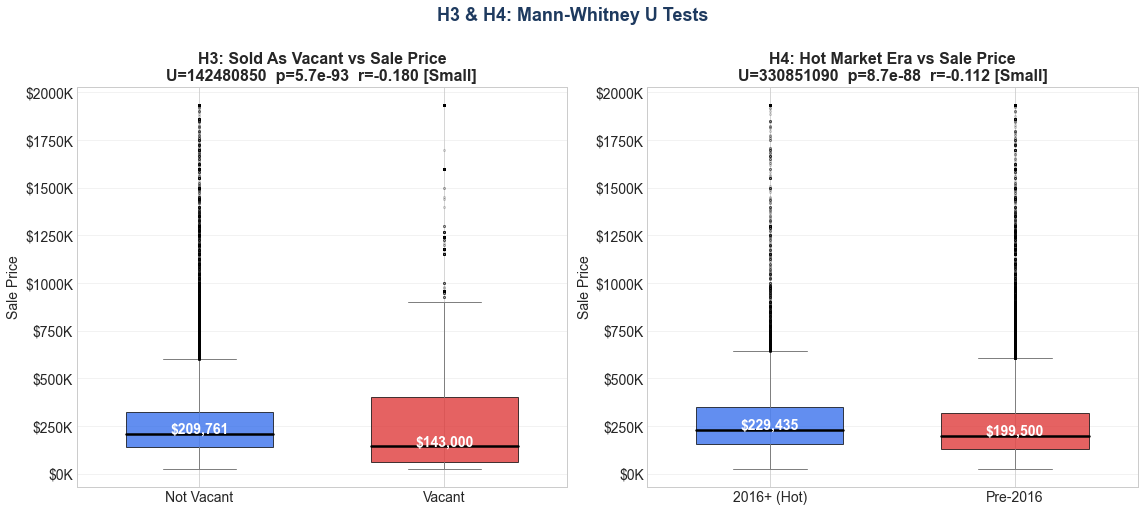

In [21]:
fig2, axes = plt.subplots(1, 2, figsize=(16, 7))
fig2.suptitle("H3 & H4: Mann-Whitney U Tests",
              fontsize=18, fontweight="bold", color="#1E3A5F", y=1.01)
 
for ax, (g1_label, g1_vals), (g2_label, g2_vals), title, U, p, r, test_label in [
    (axes[0],
     ("Not Vacant", not_vacant), ("Vacant", vacant),
     f"H3: Sold As Vacant vs Sale Price\nU={U3:.0f}  p={p3:.1e}  r={r3:.3f} [{effect_label(r3,'r')}]",
     U3, p3, r3, "Sold As Vacant"),
    (axes[1],
     ("2016+ (Hot)", post), ("Pre-2016", pre),
     f"H4: Hot Market Era vs Sale Price\nU={U4:.0f}  p={p4:.1e}  r={r4:.3f} [{effect_label(r4,'r')}]",
     U4, p4, r4, "Market Era"),
]:
    bp = ax.boxplot([g1_vals, g2_vals], patch_artist=True, notch=False,
                    medianprops=dict(color="black", linewidth=2.5),
                    flierprops=dict(marker="o", markersize=2, alpha=0.2),
                    whiskerprops=dict(color="gray"), capprops=dict(color="gray"), widths=0.6)
    
    for patch, color in zip(bp["boxes"], [BLUE, CORAL]):
        patch.set_facecolor(color); patch.set_alpha(0.72)
        
    ax.set_xticklabels([g1_label, g2_label], fontsize=14)
    
    ax.set_title(title, fontsize=16, fontweight="bold")
    ax.set_ylabel("Sale Price", fontsize = 14)
    ax.tick_params(labelsize=14)
    ax.grid(axis="y", alpha=0.3)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"${x/1e3:.0f}K"))
    
    # Annotate medians
    for i, vals in enumerate([g1_vals, g2_vals], 1):
        ax.text(i, np.median(vals)*1.02, f"${np.median(vals):,.0f}",
                ha="center", fontsize=14, color="white", fontweight="bold")

        
plt.tight_layout()

plt.show()

#### (3) Decade Built + Spearman heatmap

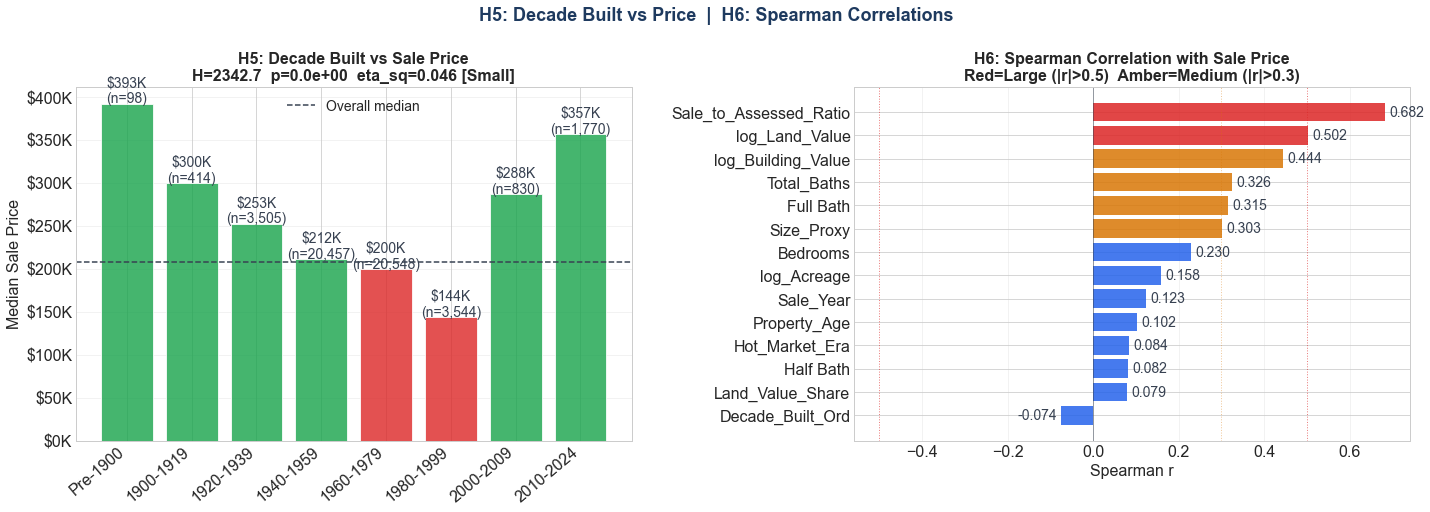

In [22]:
fig3, axes = plt.subplots(1, 2, figsize=(20, 7))
fig3.suptitle("H5: Decade Built vs Price  |  H6: Spearman Correlations",
              fontsize=18, fontweight="bold", color="#1E3A5F", y = 1.01)
 
# H5: Decade median + n
ax = axes[0]
dec_stats = (res_dec.groupby("Decade_Built", observed=True)["Sale Price"]
                    .agg(["median","count"]).reindex(DECADE_ORDER))

colors_dec = [GREEN if m > res["Sale Price"].median() else CORAL
              for m in dec_stats["median"]]

bars = ax.bar(range(len(dec_stats)), dec_stats["median"]/1000,
              color=colors_dec, alpha=0.8, edgecolor="white")

ax.axhline(res["Sale Price"].median()/1000, color=GRAY, linewidth=1.5,
           linestyle="--", label="Overall median")

for i, (bar, (_, row)) in enumerate(zip(bars, dec_stats.iterrows())):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
            f"${row['median']/1000:.0f}K\n(n={int(row['count']):,})",
            ha="center", fontsize=14, color=GRAY)
    
ax.set_xticks(range(len(dec_stats)))
ax.set_xticklabels(DECADE_ORDER, rotation=40, ha="right", fontsize=14)
ax.set_title(f"H5: Decade Built vs Sale Price\n"
             f"H={H5:.1f}  p={p5:.1e}  eta_sq={eta5:.3f} [{effect_label(eta5)}]",
             fontsize=16, fontweight="bold")
ax.set_ylabel("Median Sale Price", fontsize = 16)
ax.tick_params(labelsize=16)

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"${x:.0f}K"))
ax.legend(fontsize=14, loc = "upper center")
ax.grid(axis="y", alpha=0.3)
 
# H6: Spearman bar chart
ax = axes[1]
corr_plot = corr_df.copy()
corr_plot["abs_r"] = corr_plot["r"].abs()
corr_plot = corr_plot.sort_values("r", ascending=True)
bar_colors = [CORAL if abs(r) >= 0.5 else (AMBER if abs(r) >= 0.3 else BLUE)
              for r in corr_plot["r"]]
bars = ax.barh(corr_plot["Feature"], corr_plot["r"],
               color=bar_colors, alpha=0.85, edgecolor="none")

ax.axvline(0, color=GRAY, linewidth=1, alpha=0.5)
ax.axvline(0.5,  color=CORAL, linewidth=1, linestyle=":", alpha=0.6)
ax.axvline(-0.5, color=CORAL, linewidth=1, linestyle=":", alpha=0.6)
ax.axvline(0.3,  color=AMBER, linewidth=1, linestyle=":", alpha=0.4)

ax.set_title("H6: Spearman Correlation with Sale Price\n"
             "Red=Large (|r|>0.5)  Amber=Medium (|r|>0.3)",
             fontsize=16, fontweight="bold")
ax.tick_params(labelsize=16)

ax.set_xlabel("Spearman r", fontsize = 16)
ax.grid(axis="x", alpha=0.3)
for bar, (_, row) in zip(bars, corr_plot.iterrows()):
    v = row["r"]
    ax.text(v+(0.01 if v>=0 else -0.01), bar.get_y()+bar.get_height()/2,
            f"{v:.3f}", va="center", ha="left" if v>=0 else "right",
            fontsize=14, color=GRAY)

plt.tight_layout()
plt.subplots_adjust(wspace=0.4)

plt.show()

#### (4) Post-hoc Dunn: Land Use

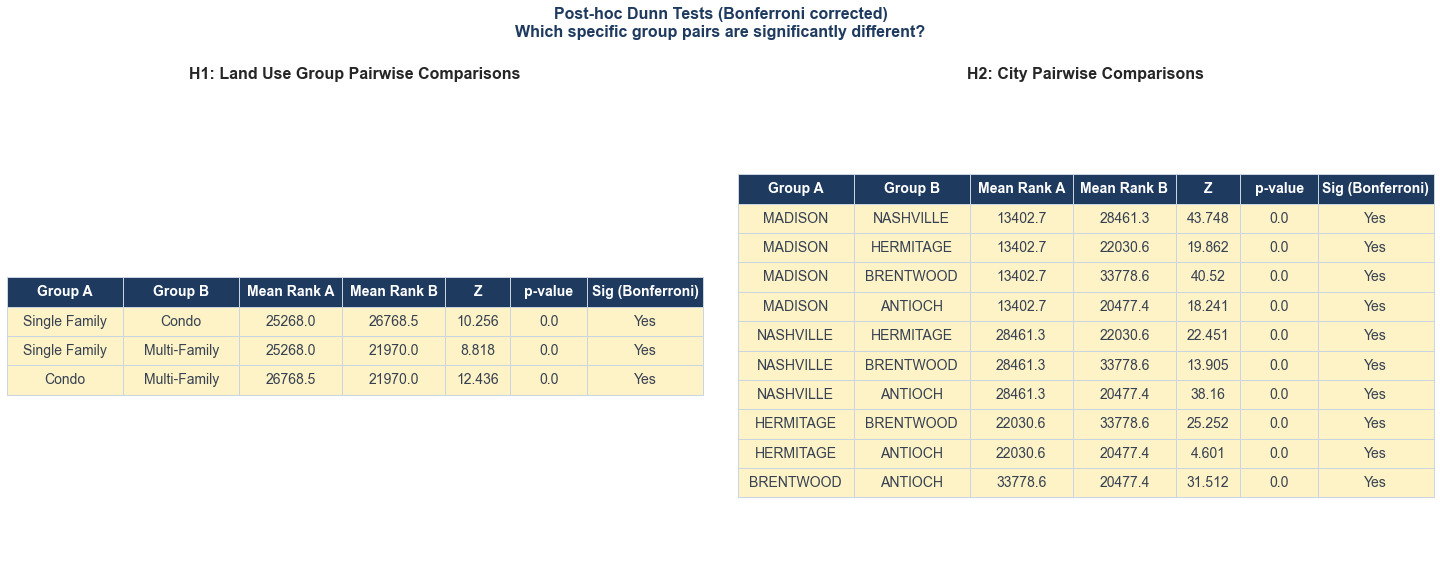

In [23]:
fig4, axes = plt.subplots(1, 2, figsize=(21, 8))
fig4.suptitle("Post-hoc Dunn Tests (Bonferroni corrected)\n"
              "Which specific group pairs are significantly different?",
              fontsize=16, fontweight="bold", color="#1E3A5F", y = 1.01)
 
for ax, dunn_df, title in [
    (axes[0], dunn1, "H1: Land Use Group Pairwise Comparisons"),
    (axes[1], dunn2, "H2: City Pairwise Comparisons"),
]:
    ax.axis("off")
    display_cols = ["Group A","Group B","Mean Rank A","Mean Rank B","Z","p-value","Sig (Bonferroni)"]
    tbl = ax.table(cellText=dunn_df[display_cols].values,
                   colLabels=display_cols, cellLoc="center", loc="center",
                  colWidths=[0.18, 0.18, 0.16, 0.16, 0.10, 0.12, 0.18, 0.18])
    
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(14)
    tbl.scale(1.5, 2.2)
    
    for (r, c), cell in tbl.get_celld().items():
        if r == 0:
            cell.set_facecolor("#1E3A5F"); cell.set_text_props(color="white", fontweight="bold")
        else:
            sig_val = dunn_df[display_cols[-1]].iloc[r-1] if r <= len(dunn_df) else ""
            cell.set_facecolor("#FEF3C7" if "Yes" in str(sig_val) else "#F8FAFC")
            cell.set_text_props(color=GRAY)
        cell.set_edgecolor("#CBD5E1")
    ax.set_title(title, fontsize=16, fontweight="bold", pad=15)

    
plt.tight_layout()
plt.subplots_adjust(wspace=0.7)
plt.show()